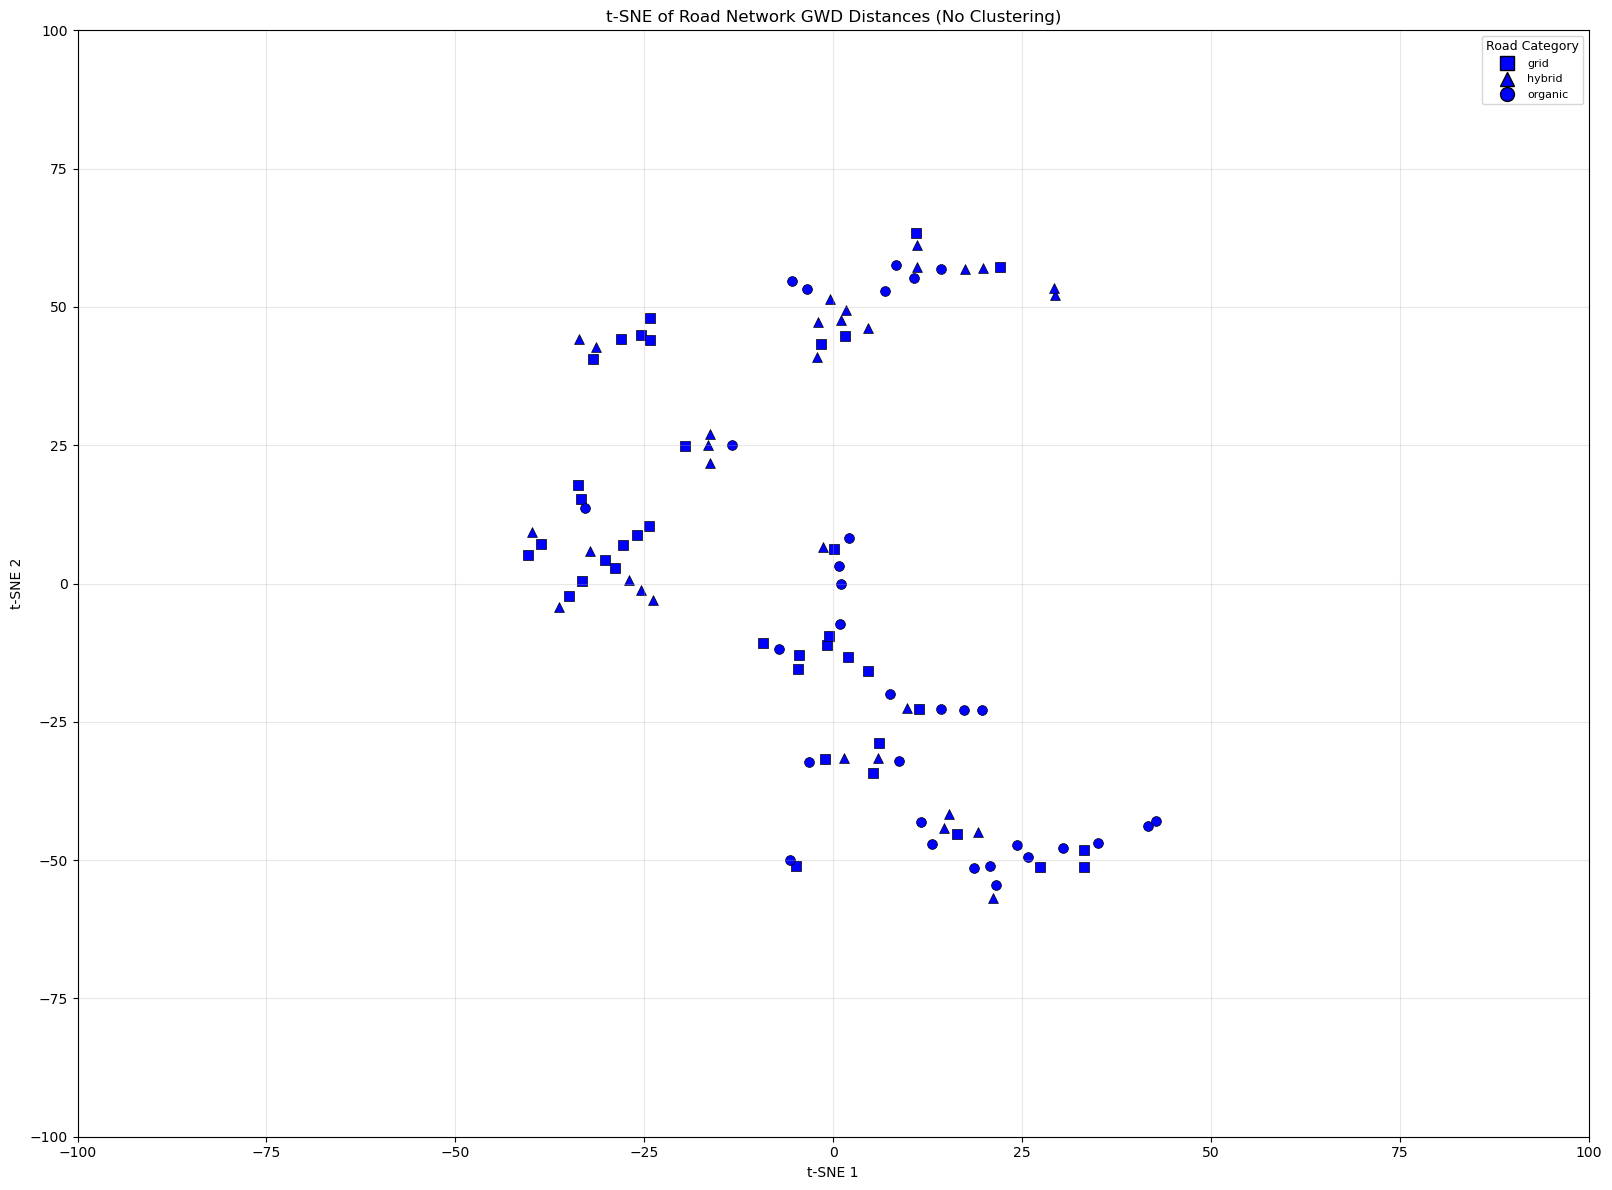

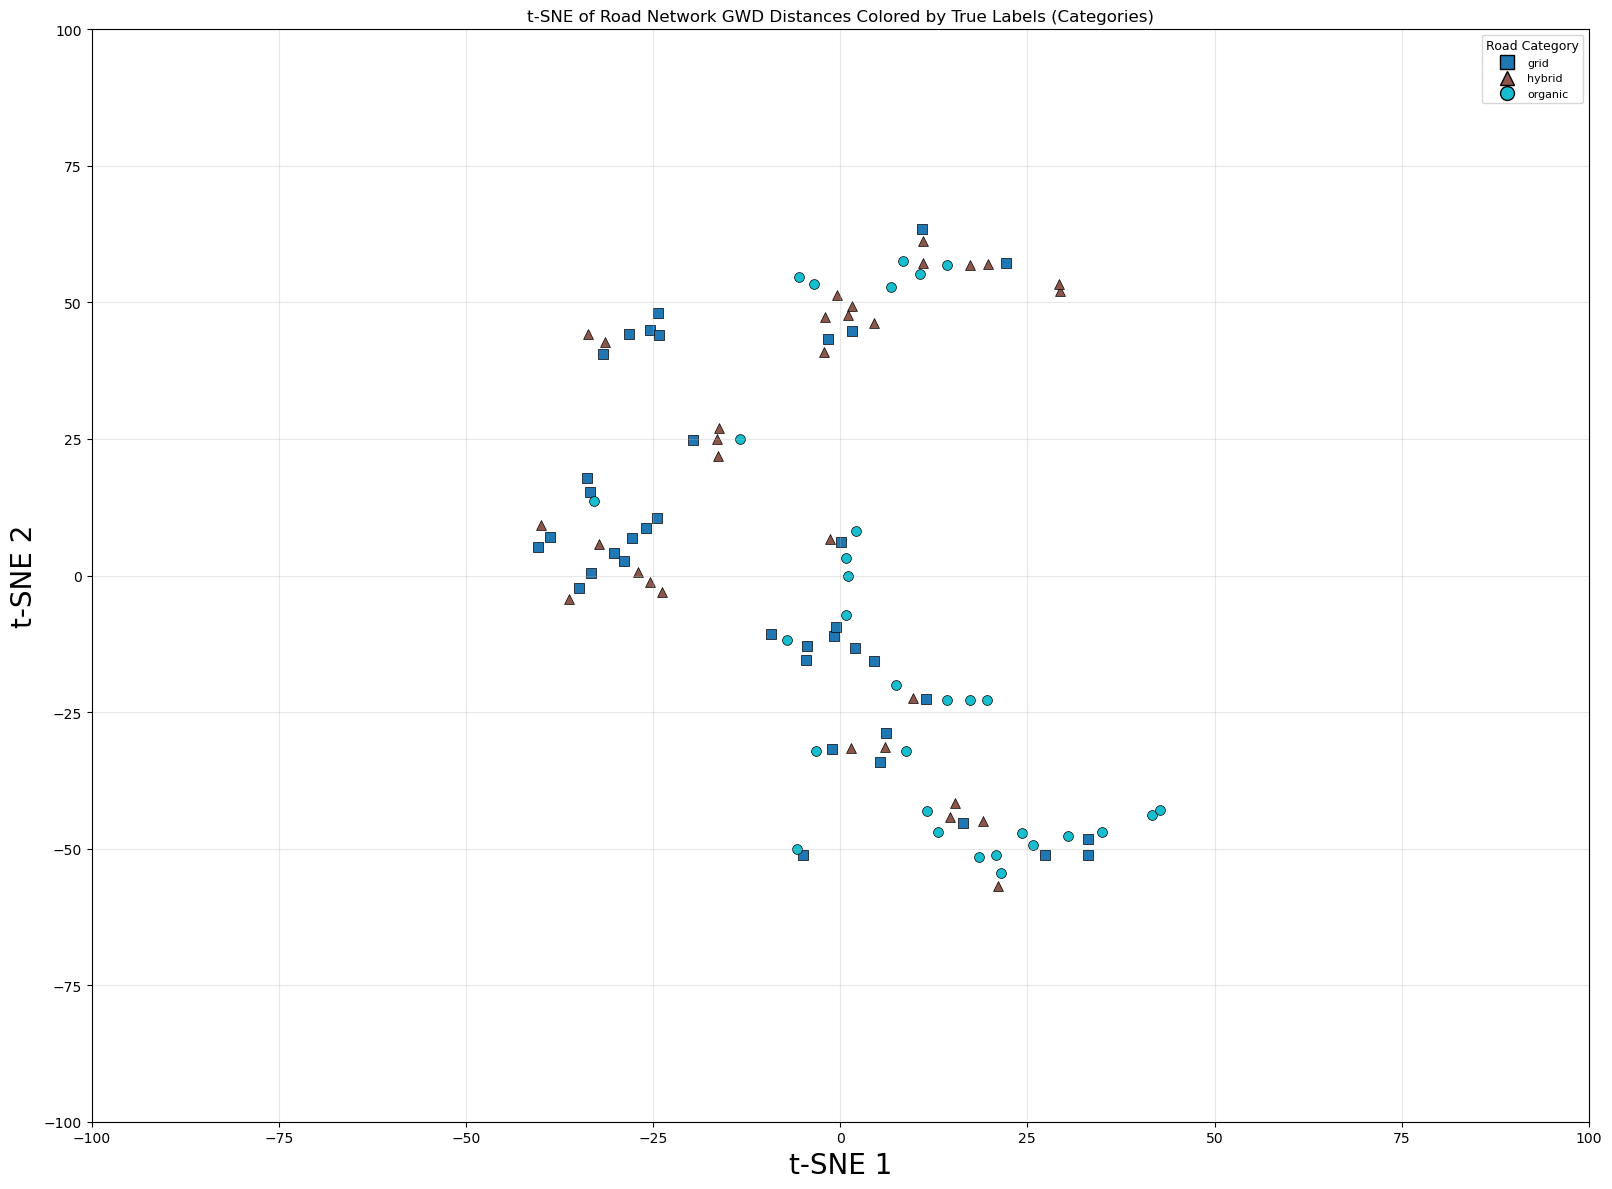

Adjusted Rand Index between true labels and cluster labels: 0.0929


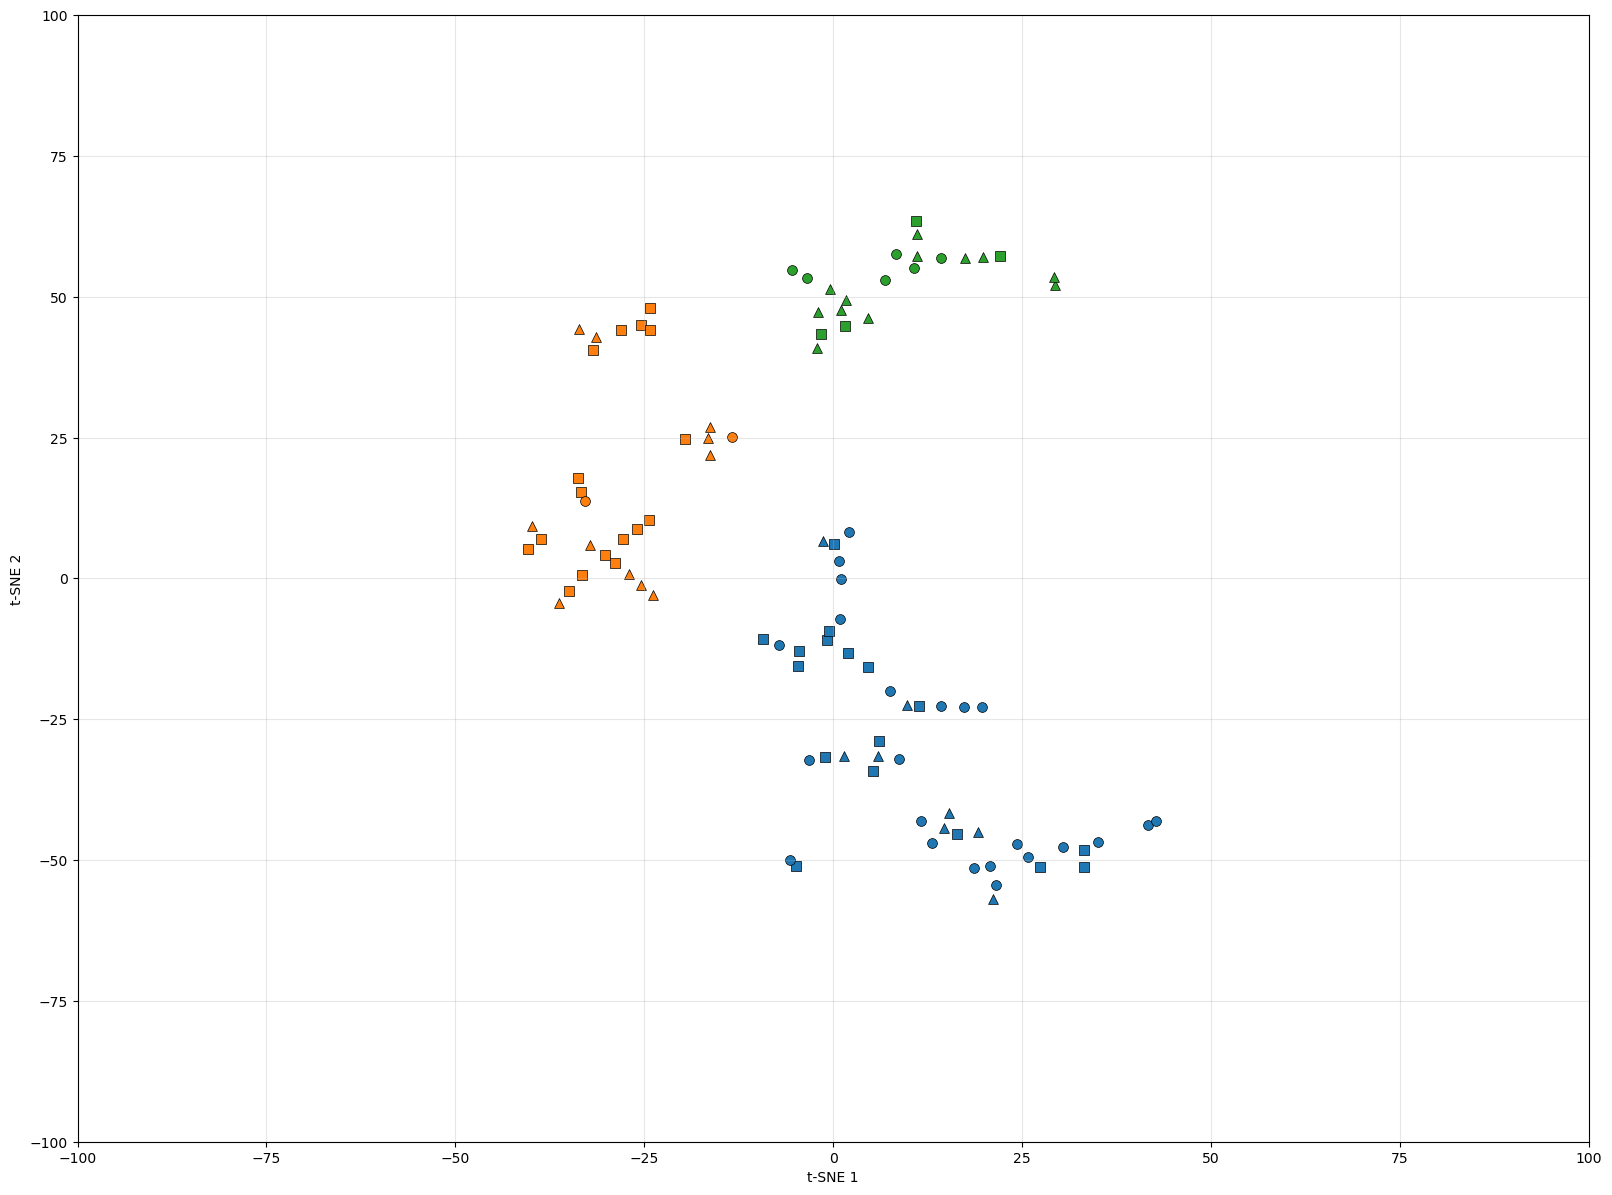

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
from matplotlib.lines import Line2D
from scipy.spatial.distance import cdist
import networkx as nx
import pickle


csv_path = 'road_gwd_distance_matrix.csv'
df_gwd = pd.read_csv(csv_path, index_col=0)

dist_matrix = df_gwd.values
sample_ids = df_gwd.index.tolist()

categories = [name.split('/')[0] for name in sample_ids]

labels_path = 'road_gwd_labels.npy'
if os.path.exists(labels_path):
    true_labels = np.load(labels_path)
else:
    
    unique_categories = sorted(set(categories))
    category_map = {c: i for i, c in enumerate(unique_categories)}
    true_labels = np.array([category_map[c] for c in categories])
# Perform t-SNE
tsne = TSNE(
    n_components=2,
    metric="precomputed",
    init='random',
    random_state=42,
    perplexity=2,
    learning_rate=100,
    n_iter=1000
)
tsne_coords = tsne.fit_transform(dist_matrix)
# Create DataFrame for plotting
df_plot = pd.DataFrame({
    "x": tsne_coords[:, 0],
    "y": tsne_coords[:, 1],
    "category": categories,
    "graph": sample_ids,
    "true_label": true_labels
})

# Map graph names to their categories
graph_to_category = dict(zip(sample_ids, categories))


category_markers = {
    'organic': 'o', # circle
    'grid': 's', # square
    'hybrid': '^' # triangle
}

# Plot t-SNE without clustering 
plt.figure(figsize=(16, 12))
unique_categories = np.unique(df_plot['category'])
for _, row in df_plot.iterrows():
    marker = category_markers.get(row['category'], 'o')
    plt.scatter(
        row['x'],
        row['y'],
        color='blue',
        marker=marker,
        s=50,
        edgecolor='k',
        linewidth=0.5
    )
# Legend for categories (markers)
legend_elements = [
    Line2D([0], [0], marker=category_markers.get(category, 'o'), color='w', label=category,
           markerfacecolor='blue', markeredgecolor='k', markersize=10)
    for category in unique_categories
]
plt.legend(handles=legend_elements, title="Road Category", loc='upper right',
           fontsize=8, title_fontsize=9)
plt.title("t-SNE of Road Network GWD Distances (No Clustering)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.show()

# Plot t-SNE colored by true labels (categories) for comparison
plt.figure(figsize=(16, 12))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_categories)))
category_color_map = dict(zip(unique_categories, colors))
for _, row in df_plot.iterrows():
    color = category_color_map[row['category']]
    marker = category_markers.get(row['category'], 'o')
    plt.scatter(
        row['x'],
        row['y'],
        color=color,
        marker=marker,
        s=50,
        edgecolor='k',
        linewidth=0.5
    )
# Legend for categories
legend_elements = [
    Line2D([0], [0], marker=category_markers.get(category, 'o'), color='w', label=category,
           markerfacecolor=category_color_map[category], markeredgecolor='k', markersize=10)
    for category in unique_categories
]
plt.legend(handles=legend_elements, title="Road Category", loc='upper right',
           fontsize=8, title_fontsize=9)
plt.title("t-SNE of Road Network GWD Distances Colored by True Labels (Categories)")
plt.xlabel("t-SNE 1", fontsize =20)
plt.ylabel("t-SNE 2", fontsize =20)

plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.savefig('road.png', dpi=300)
plt.show()

# Perform Agglomerative Clustering on t-SNE coordinates

n_clusters = 3
agglo = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='euclidean',
    linkage='ward'
)
cluster_labels = agglo.fit_predict(tsne_coords)

df_plot['cluster'] = cluster_labels

# Adjusted Rand Index
ari_score = adjusted_rand_score(true_labels, cluster_labels)
print(f"Adjusted Rand Index between true labels and cluster labels: {ari_score:.4f}")

# Compute centroids
centroids = df_plot.groupby('cluster')[['x', 'y']].mean().reset_index()

# Plot t-SNE with clustering 
plt.figure(figsize=(16, 12))
cmap = plt.get_cmap("tab10")
cluster_names = [f"Cluster {i}" for i in range(n_clusters)]
for _, row in df_plot.iterrows():
    color = cmap(row['cluster'] % 10)
    marker = category_markers.get(row['category'], 'o')
    plt.scatter(
        row['x'],
        row['y'],
        color=color,
        marker=marker,
        s=50,
        edgecolor='k',
        linewidth=0.5
    )
# Legend for clusters
legend_elements_clusters = [
    Line2D([0], [0], marker='o', color='w', label=cluster_names[c],
           markerfacecolor=cmap(c % 10), markersize=10)
    for c in range(n_clusters)
]
# plt.legend(handles=legend_elements_clusters,
# title="Agglo Clusters",
# loc='upper right',
# fontsize=8,
# title_fontsize=9)
# plt.scatter(centroids['x'], centroids['y'],
# c='black', marker='X', s=200,
# label='Centroids')
# for _, row in centroids.iterrows():
# plt.text(row['x'], row['y'], f"{int(row['cluster'])}",
# color='white', weight='bold',
# ha='center', va='center')
# plt.title("t-SNE of Road Network GWD Distances + Agglomerative Clustering")

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.xlim(-100, 100)
plt.ylim(-100, 100)
# plt.savefig('road_gwd.png', dpi=300)
plt.show()


# Function to find cluster center (closest graph to centroid)
def find_cluster_center(df, cluster_id):
    cluster_df = df[df['cluster'] == cluster_id]
    if cluster_df.empty:
        return None, None
    centroid = np.array([cluster_df['x'].mean(), cluster_df['y'].mean()])
    cluster_coords = cluster_df[['x', 'y']].to_numpy()
    distances = cdist([centroid], cluster_coords, metric='euclidean')[0]
    closest_idx = np.argmin(distances)
    closest_graph = cluster_df.iloc[closest_idx]['graph']
    return closest_graph, centroid
   
# Function to plot road network structure
def plot_road_structure(graph_name, category, cluster_id):
   
    core_path = '../pkl/city_graphs' # Adjust this path as needed
    # The graph_name is "category/original_name", original_name may have spaces
    original_name = graph_name.split('/')[-1]
    file_base = original_name.replace(' ', '_')
    file_path = os.path.join(core_path, f"{file_base}.pkl")
  
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return
  
    # Load the graph
    with open(file_path, 'rb') as f:
        G = pickle.load(f)
  
    # Set 'o' if not already (from load_city_graph logic)
    for node, data in G.nodes(data=True):
        if 'o' not in data:
            data['o'] = np.array([data.get('x', 0), data.get('y', 0)])
  
    # Plot the structure (2D projection: x vs y)
    fig, ax = plt.subplots(figsize=(8, 8))
    for u, v in G.edges():
        pos_u = G.nodes[u]['o']
        pos_v = G.nodes[v]['o']
        ax.plot([pos_u[0], pos_v[0]], [pos_u[1], pos_v[1]], 'k-', linewidth=1.5)
  
    plt.title(f"Road Network Structure: {graph_name} ({category}, {cluster_names[cluster_id]})")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis('equal')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()




# # Function to find cluster center (closest graph to centroid)
# def find_cluster_center(df, cluster_id):
#     cluster_df = df[df['cluster'] == cluster_id]
#     if cluster_df.empty:
#         return None, None
#     centroid = np.array([cluster_df['x'].mean(), cluster_df['y'].mean()])
#     cluster_coords = cluster_df[['x', 'y']].to_numpy()
#     distances = cdist([centroid], cluster_coords, metric='euclidean')[0]
#     closest_idx = np.argmin(distances)
#     closest_graph = cluster_df.iloc[closest_idx]['graph']
#     return closest_graph, centroid

# # Print centers for each cluster (no structure plotting for roads)
# for cluster_id in range(n_clusters):
#     closest_graph, centroid = find_cluster_center(df_plot, cluster_id)
#     if closest_graph is None:
#         print(f"Cluster {cluster_id} is empty")
#         continue
#     category = graph_to_category[closest_graph]
#     print(f"Cluster {cluster_id} center: {closest_graph} ({category})")